<a href="https://colab.research.google.com/github/hazelosijaja23/Impact-of-Ai-on-Students-classification-burnout/blob/main/borrador_impact-of-ia-on-students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Impacto de la IA en los estudiantes
Un conjunto de datos completo que recoge cómo el uso de herramientas de IA Generativa influye en el rendimiento de los estudiantes, el desarrollo de habilidades, la salud mental y el riesgo de agotamiento en 50.000 estudiantes.

#Clasificacion
de tres clases
low, Medium,high

In [1]:
# Download latest version
import kagglehub

# Download latest version
path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-impact-on-students' dataset.
Path to dataset files: /kaggle/input/ai-impact-on-students


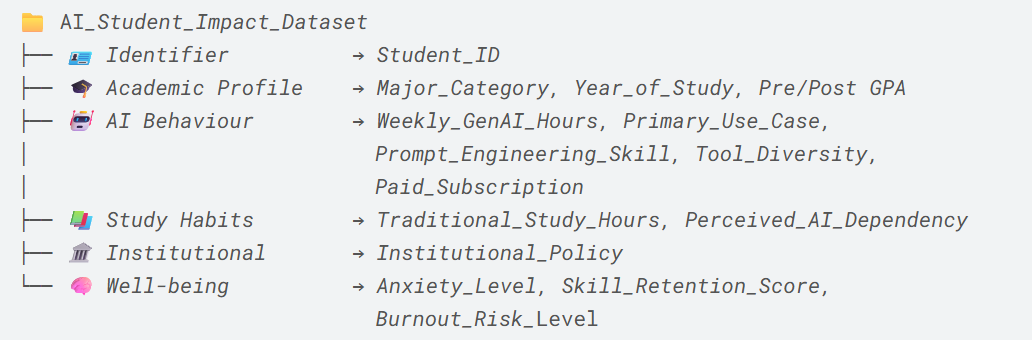

In [2]:
import pandas as panda
import os
#cargar el data set a CSV
csv=os.path.join(path,os.listdir(path)[0])
data=panda.read_csv(csv)
print(data.shape)
print(data.head())
print(data.columns.tolist())
#podemos ver que son 50mil personas con 16  datos, numericos como categoricos.


(50000, 16)
   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001     Humanities        Senior             2.418   
1      100002        Medical        Junior             3.821   
2      100003       Business      Freshman             3.398   
3      100004       Business        Senior             3.789   
4      100005           STEM     Sophomore             3.635   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0               23.31       Copywriting/Drafting                 Beginner   
1                1.12                   Ideation                 Advanced   
2               21.26        Summarizing_Reading                 Beginner   
3                1.82       Copywriting/Drafting             Intermediate   
4                9.29  Debugging/Troubleshooting                 Advanced   

   Tool_Diversity  Paid_Subscription  Traditional_Study_Hours  \
0               1               True                     8.13   
1         

In [3]:
#datos faltantes
datos_faltante= data.isnull().sum()
print("valore faltantes por columna")
print(datos_faltante)
print("total",datos_faltante.sum())

valore faltantes por columna
Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64
total 0


In [4]:
#como hay variables categoricas es importante ver si son consostentes.
datos_categoricos= data.select_dtypes(include="object")
for columna in datos_categoricos:
    print(f"\n{columna}")
    print(data[columna].value_counts(dropna=False))



Major_Category
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

Year_of_Study
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

Primary_Use_Case
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

Prompt_Engineering_Skill
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

Institutional_Policy
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

Burnout_Risk_Level
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


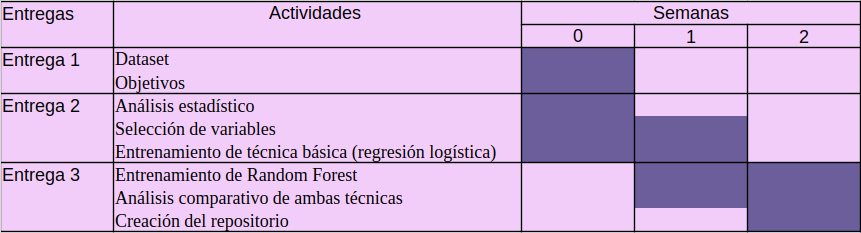

In [5]:
#como vimos arriba  hay variables categoricas
#identificar las columnas categoricas
print(data.dtypes)

Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object


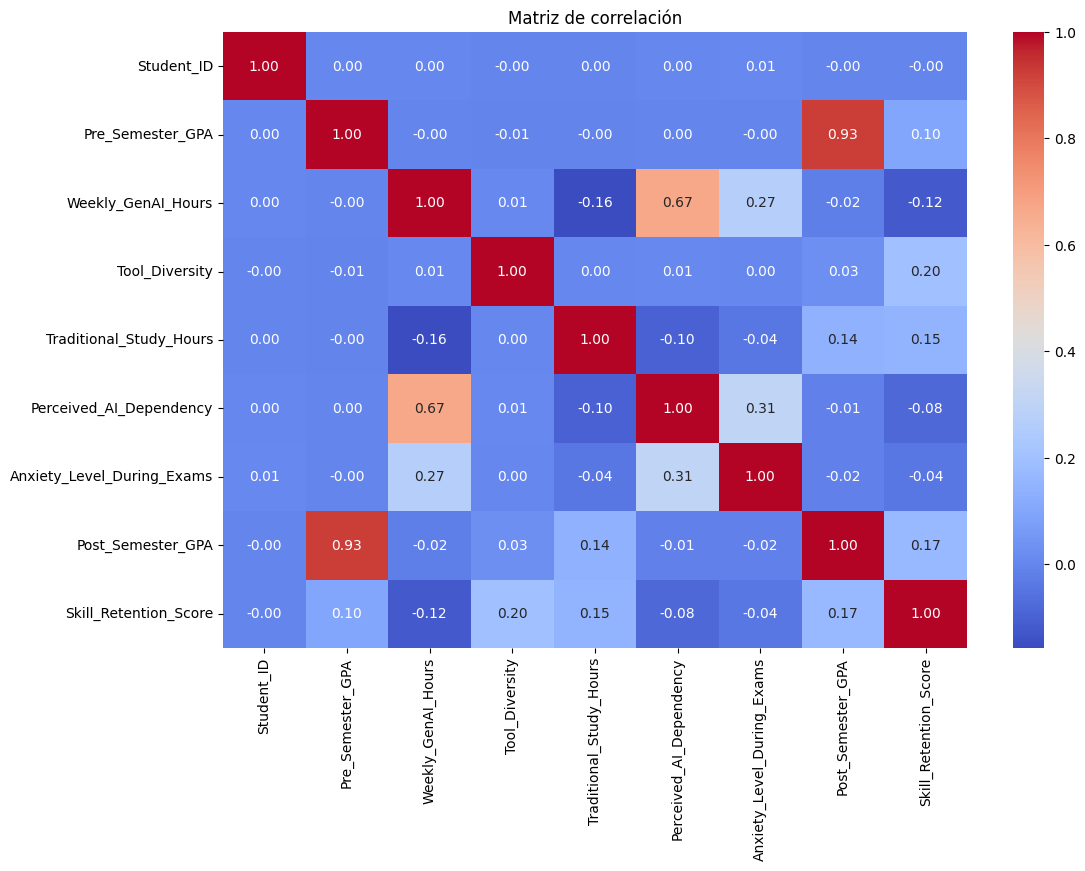

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables numéricas
num_cols = data.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,8))
sns.heatmap(
    data[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación")
plt.show()

In [7]:
# ==================================
# Feature Engineering
# ==================================

# Ratio de dependencia tecnológica
data['AI_Study_Ratio'] = (
    data['Weekly_GenAI_Hours'] /
    (data['Traditional_Study_Hours'] + 1)
)

# Cambio en el rendimiento académico
data['GPA_Delta'] = (
    data['Post_Semester_GPA']
    - data['Pre_Semester_GPA']
)

# Carga de estrés combinada
data['Combined_Stress'] = (
    data['Anxiety_Level_During_Exams']
    * data['Perceived_AI_Dependency']
)

In [8]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Define X and y (assuming 'data' is available from previous cells)
X = data.drop(['Student_ID', 'Burnout_Risk_Level'], axis=1)
y = data['Burnout_Risk_Level']

# Identify numerical and categorical features from X
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'bool']).columns

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

lr_model = Pipeline([

    ('preprocessor', preprocessor),

    ('pca',
        PCA(
            n_components=0.95,
            random_state=42
        )
    ),

    ('classifier',
        LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            multi_class='multinomial'
        )
    )

])

In [10]:
# Verifica si las clases están balanceadas
print(y.value_counts(normalize=True))
#Medium = 42.3%
#Low = 32.7%
#High = 25.0%


Burnout_Risk_Level
Medium    0.42288
Low       0.32738
High      0.24974
Name: proportion, dtype: float64


In [11]:
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_lr = {

    'pca__n_components': [
        0.90,
        0.95,
        0.98
    ],

    'classifier__C': [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],

    'classifier__solver': [
        'lbfgs',
        'saga'
    ]
}
grid_lr = GridSearchCV(

    estimator=lr_model,

    param_grid=param_grid_lr,

    scoring='f1_macro',

    cv=cv,

    n_jobs=-1,

    verbose=2

)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

print(grid_lr.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{'classifier__C': 10, 'classifier__solver': 'lbfgs', 'pca__n_components': 0.98}


In [12]:
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

print(grid_lr.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{'classifier__C': 10, 'classifier__solver': 'lbfgs', 'pca__n_components': 0.98}


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([

    ('preprocessor', preprocessor),

    ('classifier',
        RandomForestClassifier(
            random_state=42,
            class_weight='balanced_subsample'
        )
    )

])

In [14]:
param_grid_rf = {

    'classifier__n_estimators': [
        200,
        300,
        500
    ],

    'classifier__max_depth': [
        15,
        20,
        25
    ],

    'classifier__min_samples_split': [
        5,
        10
    ],

    'classifier__min_samples_leaf': [
        2,
        4
    ],

    'classifier__max_features': [
        'sqrt',
        'log2'
    ]
}

In [15]:
grid_rf = GridSearchCV(

    estimator=rf_model,

    param_grid=param_grid_rf,

    scoring='f1_macro',

    cv=cv,

    n_jobs=-1,

    verbose=2

)

In [18]:
import pandas as pd

# Make predictions using the best Logistic Regression model
pred_lr = best_lr.predict(X_test)

# Fit the Random Forest model and make predictions
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
pred_rf = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados = pd.DataFrame({

    'Modelo':[
        'Logistic Regression',
        'Random Forest'
    ],

    'Accuracy':[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_rf)
    ],

    'Precision Macro':[
        precision_score(y_test,pred_lr,average='macro'),
        precision_score(y_test,pred_rf,average='macro')
    ],

    'Recall Macro':[
        recall_score(y_test,pred_lr,average='macro'),
        recall_score(y_test,pred_rf,average='macro')
    ],

    'F1 Macro':[
        f1_score(y_test,pred_lr,average='macro'),
        f1_score(y_test,pred_rf,average='macro')
    ]

})

print(resultados)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


                Modelo  Accuracy  Precision Macro  Recall Macro  F1 Macro
0  Logistic Regression    0.5149         0.517104      0.541394  0.517852
1        Random Forest    0.5226         0.532164      0.532031  0.531057


In [ ]:
from sklearn.metrics import balanced_accuracy_score

print(
    balanced_accuracy_score(
        y_test,
        pred_lr
    )
)

print(
    balanced_accuracy_score(
        y_test,
        pred_rf
    )
)

In [ ]:
from sklearn.metrics import cohen_kappa_score

print(
    cohen_kappa_score(
        y_test,
        pred_lr
    )
)

print(
    cohen_kappa_score(
        y_test,
        pred_rf
    )
)

In [ ]:
from sklearn.metrics import matthews_corrcoef

print(
    matthews_corrcoef(
        y_test,
        pred_lr
    )
)

print(
    matthews_corrcoef(
        y_test,
        pred_rf
    )
)

In [ ]:
from sklearn.metrics import classification_report

rep_lr = classification_report(
    y_test,
    pred_lr,
    output_dict=True
)

rep_rf = classification_report(
    y_test,
    pred_rf,
    output_dict=True
)

comparacion = pd.DataFrame({

    'Clase':['Low','Medium','High'],

    'Recall LR':[
        rep_lr['Low']['recall'],
        rep_lr['Medium']['recall'],
        rep_lr['High']['recall']
    ],

    'Recall RF':[
        rep_rf['Low']['recall'],
        rep_rf['Medium']['recall'],
        rep_rf['High']['recall']
    ]

})

print(comparacion)

In [ ]:
coeficientes = pd.DataFrame({

    'Variable':feature_names,

    'Coeficiente':
        best_lr.named_steps[
            'classifier'
        ].coef_[0]

})